## Future Changes
I have been playing around with the number of trees and the slicing of the data. To finalize this part of my work, I want to run all the trees I can and use unsliced data. I will obtain several plots from this including the pred v true plots as well as my error histograms. I hope that doing a full run will improve my histograms since I used about 30 trees to then use to work on my code. I do not think my code is necessarily wrong even though the plots are not the best, I want to see if there would be a difference.

In [4]:
import polars as pl

base = "/fs/ess/PAS2159/HughesLab2/ANITA_DATA/parquet_for_fitting/"
df_training = pl.read_parquet( base + "processed_training_data.parquet")
df_test = pl.read_parquet( base + "processed_testing_data.parquet")

print("training:", df_training.shape)
print("testing:", df_test.shape)

## this first cell opens a parquet file for both the training and test data
## each row is pulled into memory as a polars dataframe
## the shape is printed merely as confirmation
## from what I understand, the point is that the machine learning model learns
## from one set of events (our training data) and then is tested on a different set
## set of events (test data) that it has not seen before
## we do not want the test data to influence our training data at all, those are separate

training: (41959, 43)
testing: (10678, 43)


In [5]:
import numpy as np

def get_X(df):
    X = df["processed_waveforms"].to_numpy()
    if X.ndim ==1:
        X = np.stack(df["processed_waveforms"].to_list())
    return X

X_training = get_X(df_training)
X_test = get_X(df_test)

y_training = df_training[["mctheta", "sin_phi", "cos_phi"]].to_numpy() ## switched mcphi to sin/cos
y_test = df_test[["mctheta", "sin_phi", "cos_phi"]].to_numpy()

phi_test_true = df_test["mcphi"].to_numpy()

print("X_training", X_training.shape, "y_training", y_training.shape)
print("X_test", X_test.shape, "y_test", y_test.shape)

## I got lazy when writing out process_waveforms (which i know is awful documentation)
## but I will say it here, X = processed_waveforms, get_X pulls the processed
## waveforms column out of the dataframe as a numpy array, ideally, we should be seeing
## a shape of (n_events, 9600)
## a couple times it was coming back as a 1D array instead, so np.stack was used to bypass that
## for the y values, the [[]] chooses two columns and converts them to a 2D array
## There is one row per event and two columns (column 0=theta, column 1=phi)

X_training (41959, 9600) y_training (41959, 3)
X_test (10678, 9600) y_test (10678, 3)


## Create a Forest

In [6]:
from sklearn.ensemble import RandomForestRegressor
import joblib

## We'll keep n_sub for now while playing with the weight, but ideally that will be gone
## i have now removed n_sub = 5000 so we are no longer slicing it and increased the number of trees
n_sub = 5000
w_train = df_training["weight"].to_numpy()[:n_sub]

print("about to train on:", X_training[:n_sub].shape,
      "y:", y_training[:n_sub].shape,
      "weights:", w_train.shape)

rf = RandomForestRegressor(n_estimators=30, n_jobs=-1, random_state=30, verbose=2)
rf.fit(X_training[:n_sub], y_training[:n_sub], sample_weight=w_train)
print("done training")

joblib.dump(rf, "rf_practice.joblib")
print("saved")

about to train on: (5000, 9600) y: (5000, 3) weights: (5000,)
building tree 1 of 30
building tree 2 of 30
building tree 3 of 30
building tree 4 of 30
building tree 5 of 30
building tree 6 of 30
building tree 7 of 30
building tree 8 of 30
building tree 9 of 30
building tree 10 of 30
building tree 11 of 30
building tree 12 of 30


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


building tree 13 of 30
building tree 14 of 30
building tree 15 of 30
building tree 16 of 30
building tree 17 of 30
building tree 18 of 30
building tree 19 of 30
building tree 20 of 30
building tree 21 of 30
building tree 22 of 30
building tree 23 of 30
building tree 24 of 30
building tree 25 of 30
building tree 26 of 30
building tree 27 of 30
building tree 28 of 30
building tree 29 of 30
building tree 30 of 30


[Parallel(n_jobs=-1)]: Done  23 out of  30 | elapsed:  2.9min remaining:   52.6s


done training
saved


[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:  3.7min finished


## Error Calculations

In [7]:
pred = rf.predict(X_test)
w_test = df_test["weight"].to_numpy()
print("pred:", pred.shape, "y_test:", y_test.shape, "w_test:", w_test.shape)

theta_pred = pred[:, 0]
theta_err  = theta_pred - y_test[:, 0]

sin_pred = pred[:, 1]
cos_pred = pred[:, 2]
phi_pred = np.degrees(np.arctan2(sin_pred, cos_pred)) % 360
phi_err = (phi_pred - phi_test_true + 180) % 360 - 180

print("UNWEIGHTED")
print(f"  theta: mean={theta_err.mean():7.3f}   std={theta_err.std():7.3f}")
print(f"  phi  : mean={phi_err.mean():7.3f}   std={phi_err.std():7.3f}")

print("WEIGHTED")
for name, err in [("theta", theta_err), ("phi", phi_err)]:
    mean_w = np.average(err, weights=w_test)
    var_w  = np.average((err - mean_w)**2, weights=w_test)
    std_w  = np.sqrt(var_w)
    print(f"  {name:5s}: mean={mean_w:7.3f}   std={std_w:7.3f}")

pred: (10678, 3) y_test: (10678, 3) w_test: (10678,)
UNWEIGHTED
  theta: mean=  0.077   std=  1.347
  phi  : mean=  0.206   std= 23.222
WEIGHTED
  theta: mean=  0.205   std=  1.345
  phi  : mean= -0.013   std= 25.531


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  23 out of  30 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=12)]: Done  30 out of  30 | elapsed:    0.0s finished


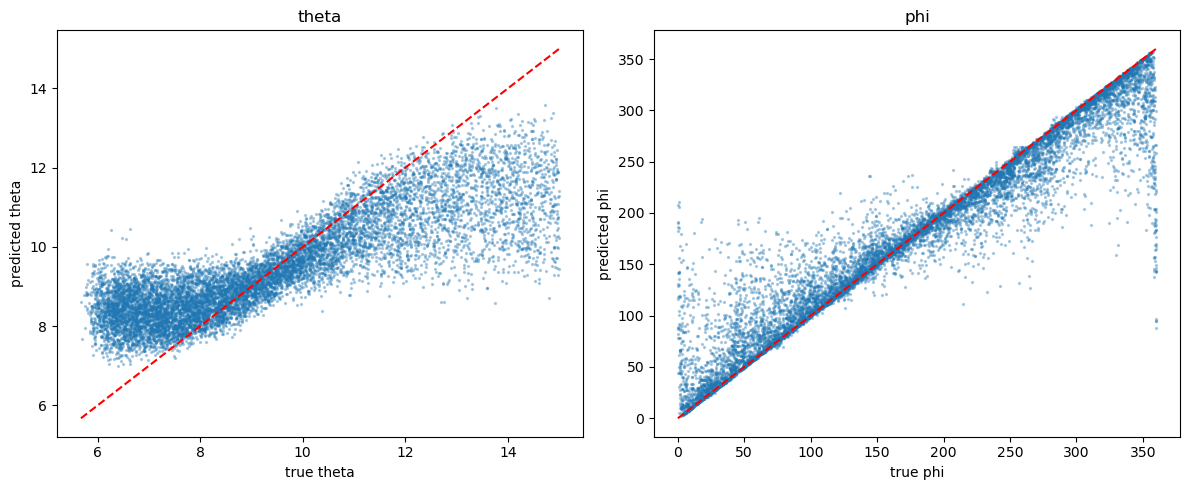

In [8]:
## first of my attempts, not using sincos. NO SINCOS

# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(1,2,figsize=(12,5))
# for ax, i, name in [(axes[0], 0, "theta"), (axes[1], 1, "phi")]:
#     ax.scatter(y_test[:, i], pred[:,i], s=2, alpha=0.3)
#     lo, hi = y_test[:, i].min(), y_test[:, i].max()
#     ax.plot([lo, hi], [lo, hi], "r--")
#     ax.set_xlabel(f"true {name}")
#     ax.set_ylabel(f"predicted {name}")
#     ax.set_title(name)
# plt.tight_layout()
# plt.show()


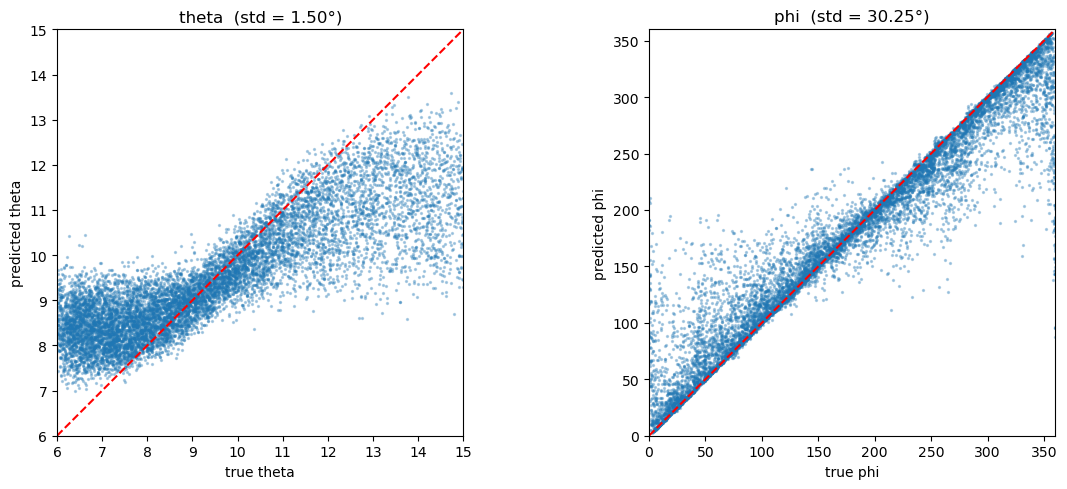

In [9]:
## this was the better of the two attempts without sin cos, moving onto sincos. NO SINCOS

# import matplotlib.pyplot as plt
# import numpy as np

# fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# # Theta on its actual range, not auto-scaled
# axes[0].scatter(y_test[:, 0], pred[:, 0], s=2, alpha=0.3)
# axes[0].plot([6, 15], [6, 15], "r--")
# axes[0].set_xlim(6, 15)
# axes[0].set_ylim(6, 15)
# axes[0].set_xlabel("true theta")
# axes[0].set_ylabel("predicted theta")
# axes[0].set_title(f"theta  (std = {(pred[:,0]-y_test[:,0]).std():.2f}°)")
# axes[0].set_aspect("equal")

# # Phi on its actual range
# phi_err = (pred[:, 1] - y_test[:, 1] + 180) % 360 - 180
# axes[1].scatter(y_test[:, 1], pred[:, 1], s=2, alpha=0.3)
# axes[1].plot([0, 360], [0, 360], "r--")
# axes[1].set_xlim(0, 360)
# axes[1].set_ylim(0, 360)
# axes[1].set_xlabel("true phi")
# axes[1].set_ylabel("predicted phi")
# axes[1].set_title(f"phi  (std = {phi_err.std():.2f}°)")
# axes[1].set_aspect("equal")

# plt.tight_layout()
# plt.show()


## Final Version - Visualization

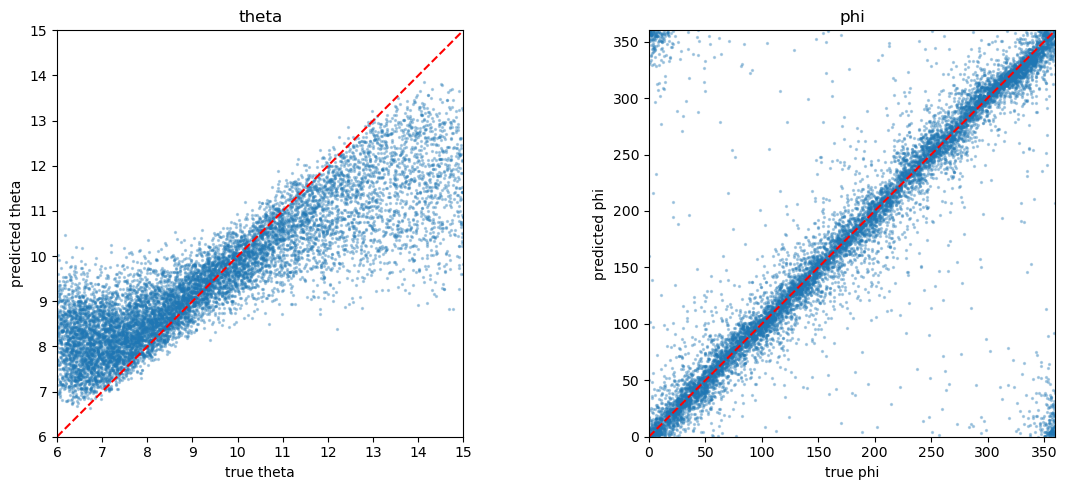

In [8]:
## plot after incorporating cos and phi 
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test[:, 0], theta_pred, s=2, alpha=0.3)
axes[0].plot([6, 15], [6, 15], "r--")
axes[0].set_xlim(6, 15); axes[0].set_ylim(6, 15); axes[0].set_aspect("equal")
axes[0].set_xlabel("true theta"); axes[0].set_ylabel("predicted theta"); axes[0].set_title("theta")

axes[1].scatter(phi_test_true, phi_pred, s=2, alpha=0.3)
axes[1].plot([0, 360], [0, 360], "r--")
axes[1].set_xlim(0, 360); axes[1].set_ylim(0, 360); axes[1].set_aspect("equal")
axes[1].set_xlabel("true phi"); axes[1].set_ylabel("predicted phi"); axes[1].set_title("phi")

plt.tight_layout()
plt.show()

## in the output of this code if n_sub =5000 and you put the slicing back in and kept 50 trees, 
## The little edges of the phi graph are interesting. I am not exactly sure what it means 
## UPDATE: this is fine! This is good, it is wrapping around it is much closer than it actually looks

## Delta Plots
For this first block, I used np.average as it seemed the most straightforward for me, but I will improve upon my work in the next block

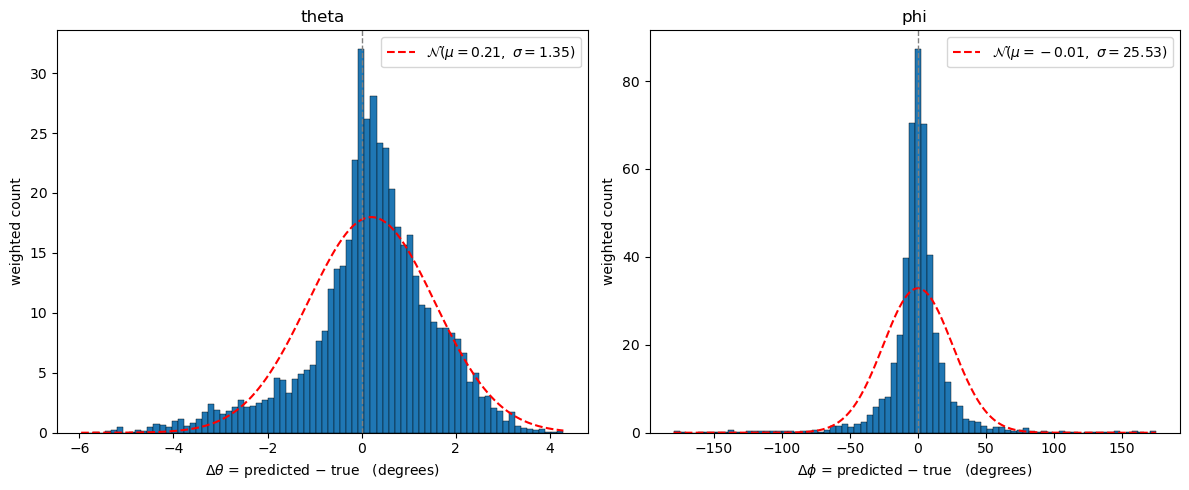

In [10]:
## delta theta and delta phi plots (not using curve_fit like Tony)
## The two will look a little different, but how different?

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(12,5))

for ax, err, name, symbol in [
    (axes[0], theta_err, "theta", r"\Delta\theta"),
    (axes[1], phi_err, "phi", r"\Delta\phi"),
]:
    n_bins = 80

    counts, edges, _ = ax.hist(
        err, bins=n_bins, weights=w_test, edgecolor="black", linewidth=0.3,)

    mu = np.average(err, weights=w_test)
    sigma = np.sqrt(np.average((err - mu)**2, weights=w_test))


    bin_width = edges[1]-edges[0]
    total_weight = w_test.sum()
    x_smooth = np.linspace(err.min(), err.max(), 400)
    gauss = total_weight*bin_width*norm.pdf(x_smooth, mu, sigma)
    ax.plot(x_smooth, gauss, "r--", linewidth=1.5, label=fr"$\mathcal{{N}}(\mu={mu:.2f},\ \sigma={sigma:.2f})$")
    ax.axvline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel(fr"${symbol}$ = predicted − true   (degrees)")
    ax.set_ylabel("weighted count")
    ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.show()

After looking at Tony's code, it seemed easier to use curve_fit so this is my attempt to use that in my own way

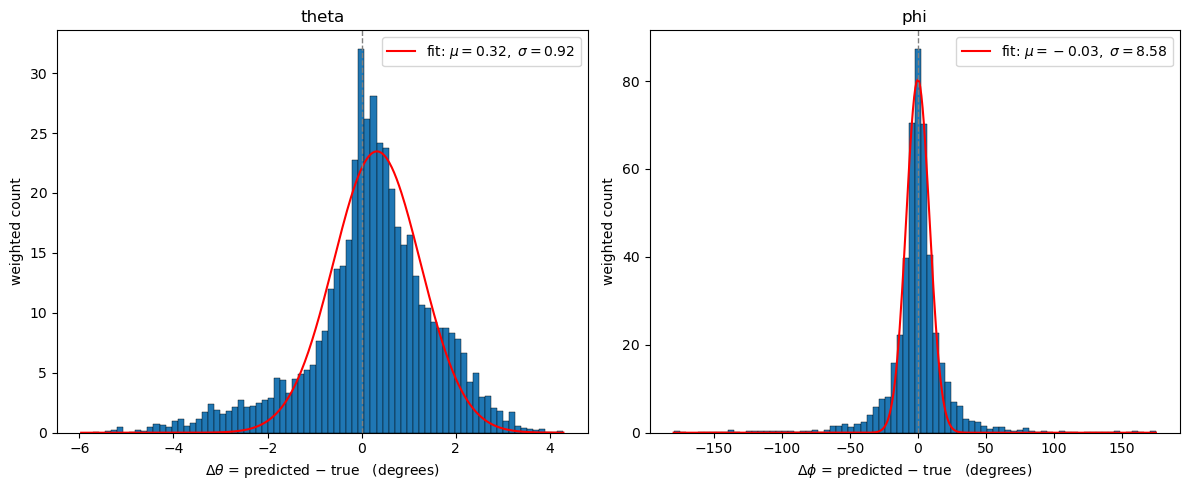

In [11]:
## My version of Tony's curve_fit code

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

def gaussian(x, amplitude, mu, sigma):
    return amplitude * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, err, name, symbol in [
    (axes[0], theta_err, "theta", r"\Delta\theta"),
    (axes[1], phi_err,   "phi",   r"\Delta\phi"),
]:
    n_bins = 80

    # Weighted histogram.
    counts, edges, _ = ax.hist(
        err, bins=n_bins, weights=w_test,
        edgecolor="black", linewidth=0.3,
    )
    centers = 0.5 * (edges[:-1] + edges[1:])

    # Fit a Gaussian to the histogram. Initial guesses from the data so curve_fit converges fast.
    p0 = [counts.max(),
          np.average(err, weights=w_test),
          np.sqrt(np.average((err - np.average(err, weights=w_test)) ** 2, weights=w_test))]
    popt, pcov = curve_fit(gaussian, centers, counts, p0=p0)
    amp_fit, mu_fit, sigma_fit = popt
    sigma_fit = abs(sigma_fit)   # curve_fit may return negative sigma; only magnitude is meaningful

    # Overlay the fitted Gaussian.
    x_smooth = np.linspace(err.min(), err.max(), 400)
    ax.plot(x_smooth, gaussian(x_smooth, *popt), "r-", linewidth=1.5,
            label=fr"fit: $\mu={mu_fit:.2f},\ \sigma={sigma_fit:.2f}$")

    ax.axvline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel(fr"${symbol}$ = predicted − true   (degrees)")
    ax.set_ylabel("weighted count")
    ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.show()

In [13]:
## Tony's curve fit code
# Fit a Gaussian distribution to the delta values to model the error distribution
from scipy.optimize import curve_fit

def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# Calculates histogram array based on (weighted) data
def histogram(data, weights=None, bins=30):
    hist, bin_edges = np.histogram(data, weights=weights, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2. # Move from edges to center of bin
    return hist, bin_centers

# Plots a histogram of delta values with an optional Gaussian fit overlay
def plot_histogram(delta_arr, title, weights, bins=30, params=None):
    
    fig, ax = plt.subplots(figsize=(6, 6))

    if weights is None:
        weights = np.ones_like(delta_arr)
    ax.hist(delta_arr, weights=weights, bins=bins, label='histogram')
    if params is not None:
        x = np.linspace(delta_arr.min(), delta_arr.max(), 100)
        fit = gaussian(x, *params)
        ax.plot(x, fit, 'r-', label='Gaussian fit')

    ax.set_title(title)
    ax.set_xlabel(r'$\Delta$')
    ax.set_ylabel('Frequency')
    fig.tight_layout()
    fig.show()
    
# Full method to determine resolution by fitting a Gaussian to the error distribution, with outlier filtering and histogram plotting
def determine_resolution(delta_arr, title, weights, bins=30):

    avg = np.average(delta_arr, weights=weights)
    std = np.sqrt(np.average((delta_arr - avg) ** 2, weights=weights))

    pre_len = len(delta_arr)

    # Cutoff to 6 sigma level
    weights = weights[np.abs(delta_arr) < 3 * std]
    delta_arr = delta_arr[np.abs(delta_arr) < 3 * std]

    print(f"Filtered {pre_len - len(delta_arr)} values")

    # Create histograms
    hist, bins = histogram(delta_arr, weights=weights, bins=bins)

    # Fit Gaussian curves to the histograms
    p_0 = [np.max(hist), avg, std]
    params, _ = curve_fit(gaussian, bins, hist, p0=p_0) # parameters, covariance output (mb use covariance later)
    plot_histogram(delta_arr, title, weights=weights, bins=bins, params=params)

    return {
        'mu': params[1],
        'sigma': params[2]
    }
